# RICS: simulate a diffusing sample, then measure its diffusion coefficient

Raster image correlation spectroscopy extracts a diffusion coefficient from an
ordinary confocal scan. It works because a raster scan is not a snapshot: the
beam visits neighbouring pixels microseconds apart and neighbouring *lines*
milliseconds apart, so how far the sample decorrelates between them is a
measurement of how fast it moves.

This notebook closes the loop on synthetic data whose answer is known by
construction:

1. **simulate** a raster scan of freely diffusing molecules with a chosen `D`;
2. **look at the images** — and at the correlation map they produce;
3. **recover** `D` by fitting the image-correlation model;
4. see **where it stops working**, and why that is physics rather than a bug.

Along the way we show three mistakes that produce a scan which looks perfectly
healthy and contains no diffusion information at all. They are worth knowing
because none of them raises an error.

Theory: *Concepts → Image correlation* and *Concepts → Planning a scan*.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from chisurf.core.experiments.ics.ics_core import compute_ics_carpet
from chisurf.core.fluorescence.imaging import simulate_clsm_diffusion
from chisurf.core.models.ics.models import image_correlation

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

## 1. Simulate a scan

`simulate_clsm_diffusion` raster-scans an **open-volume population** of
molecules through a Gaussian focus, photon by photon, and hands back the images
together with the ground truth. The scan geometry is the part that matters:
with a 250 nm waist and 50 nm pixels the focus spans about ten pixels, so
neighbouring pixels see *the same molecule*, which is exactly the correlation
RICS reads.

In [2]:
D_TRUE = 2.0  # µm²/s

scan = simulate_clsm_diffusion(
    D_TRUE,
    n_pixel=64,
    n_frames=60,
    pixel_size=0.05,   # µm
    pixel_time=2e-5,   # s
    w_r=0.25,          # µm, lateral 1/e² waist
    w_z=1.0,           # µm
    n_molecules=400.0,
    seed=1,
)

print(f"images        {scan.images.shape}  ({scan.n_photons:,} photons)")
print(f"pixel dwell   {scan.pixel_time * 1e6:.1f} µs")
print(f"line time     {scan.line_time * 1e3:.2f} ms")
print(f"frame time    {scan.frame_time * 1e3:.1f} ms")
print(f"mean signal   {scan.images.mean():.1f} counts/pixel")

images        (60, 64, 64)  (2,770,724 photons)
pixel dwell   20.0 µs
line time     1.28 ms
frame time    81.9 ms
mean signal   11.3 counts/pixel


The two time scales in that table are the whole method. Neighbouring pixels are
**20 µs** apart; neighbouring lines are **1.28 ms** apart, 64× longer. A
molecule diffusing at 2 µm²/s moves

$$\sqrt{4 D t} = \sqrt{4 \cdot 2 \cdot 20\,\mu\mathrm{s}} \approx 13\ \mathrm{nm}$$

between pixels but ~100 nm between lines — a large fraction of the 250 nm
waist. The correlation therefore decays much faster along the slow axis than
the fast one, and *that asymmetry is the signal*.

In [3]:
for label, t in (("pixel→pixel", scan.pixel_time), ("line→line", scan.line_time)):
    print(f"{label:12s} {t * 1e6:8.1f} µs → molecule moves "
          f"{np.sqrt(4 * D_TRUE * t) * 1e3:6.1f} nm  "
          f"({np.sqrt(4 * D_TRUE * t) / scan.w_r * 100:4.1f} % of the waist)")

pixel→pixel      20.0 µs → molecule moves   12.6 nm  ( 5.1 % of the waist)
line→line      1280.0 µs → molecule moves  101.2 nm  (40.5 % of the waist)


## 2. Look at the images

The sample has no structure — it is point emitters in solution — so anything
you see in a frame is a molecule caught by the beam.

Look at the **shape** of what the beam catches. Molecules appear as short
*horizontal streaks*, not round spots: the beam crosses a molecule's position
in 20 µs per pixel and so sees it several pixels in a row, but by the time it
returns 1.28 ms later on the next line the molecule has moved away. **That
elongation is the RICS signal, visible before any correlation is computed.**

The third panel zooms in so the streaking is unmistakable. (The frame average
is deliberately not shown: with only ~0.5 molecules in the focus, 60 frames is
nowhere near enough to average flat, and a blotchy mean would say more about
the frame count than about the sample.)

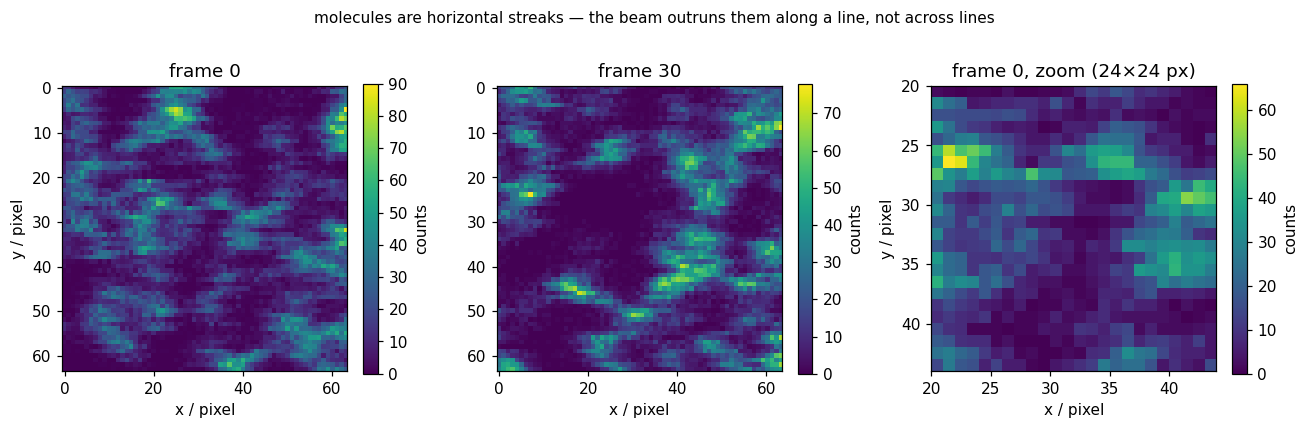

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (title, img, extent) in zip(
    axes,
    [("frame 0", scan.images[0], None),
     ("frame 30", scan.images[30], None),
     ("frame 0, zoom (24×24 px)", scan.images[0][20:44, 20:44], (20, 44, 44, 20))],
):
    m = ax.imshow(img, cmap="viridis", origin="upper", extent=extent,
                  interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("x / pixel")
    fig.colorbar(m, ax=ax, fraction=0.046, label="counts")
axes[0].set_ylabel("y / pixel")
axes[2].set_ylabel("y / pixel")
fig.suptitle("molecules are horizontal streaks — the beam outruns them along a line, "
             "not across lines", y=1.04, fontsize=10)
fig.tight_layout()

## 3. The correlation map

`compute_ics_carpet` correlates each frame with itself and averages. The result
is a map over *spatial lags*: how similar is a pixel to the one $\xi$ pixels
along the fast axis and $\psi$ lines along the slow axis.

The zero lag carries the shot-noise spike — a photon is perfectly correlated
with itself — which is not part of the model and is excluded from every fit
below.

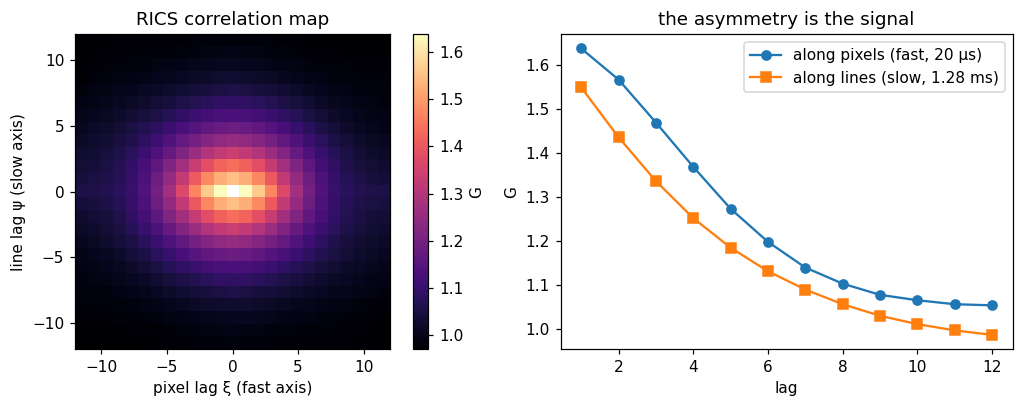

In [5]:
carpet = compute_ics_carpet(scan.images)
g = np.asarray(carpet.correlation[0], dtype=float)
cy, cx = g.shape[0] // 2, g.shape[1] // 2

n_show = 12
block = g[cy - n_show:cy + n_show + 1, cx - n_show:cx + n_show + 1]
shown = block.copy()
shown[n_show, n_show] = np.nan  # hide the shot-noise spike so the shape is visible

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.8))
m = ax0.imshow(shown, cmap="magma", origin="lower",
               extent=[-n_show, n_show, -n_show, n_show])
ax0.set(xlabel="pixel lag ξ (fast axis)", ylabel="line lag ψ (slow axis)",
        title="RICS correlation map")
fig.colorbar(m, ax=ax0, fraction=0.046, label="G")

lags = np.arange(1, n_show + 1)
ax1.plot(lags, g[cy, cx + 1:cx + n_show + 1], "o-", label="along pixels (fast, 20 µs)")
ax1.plot(lags, g[cy + 1:cy + n_show + 1, cx], "s-", label="along lines (slow, 1.28 ms)")
ax1.set(xlabel="lag", ylabel="G", title="the asymmetry is the signal")
ax1.legend()
fig.tight_layout()

The map is visibly **elongated along the fast axis**: correlation survives
further between pixels than between lines, because less time passed. That
squashing is what encodes `D`.

## 4. Recover the diffusion coefficient

`image_correlation` is the model. We fit the number of molecules `N`, the
diffusion coefficient `D` and a constant offset to the map, with the scan
timing and the optics fixed at their known values.

In [6]:
def fit_rics(scan, n_lags=10, w_r=None, region="line"):
    """Fit N and D to the RICS map of *scan*, excluding the zero-lag spike."""
    carpet = compute_ics_carpet(scan.images)
    g = np.asarray(carpet.correlation[0], dtype=float)
    cy, cx = g.shape[0] // 2, g.shape[1] // 2
    xi, psi = np.meshgrid(np.arange(-n_lags, n_lags + 1),
                          np.arange(-n_lags, n_lags + 1), indexing="xy")
    block = g[cy - n_lags:cy + n_lags + 1, cx - n_lags:cx + n_lags + 1]
    # Fit the SLOW-AXIS column only. This choice matters more than any other:
    # see the section below on why the obvious square region is a bad one.
    keep = (xi == 0) & (np.abs(psi) >= 1) if region == "line" else ~((xi == 0) & (psi == 0))

    def model(_, n, d, offset):
        return image_correlation(
            xi[keep].ravel(), psi[keep].ravel(), 0.0, n=n,
            diffusion_coefficient=d, offset=offset,
            pixel_duration=scan.pixel_time * 1e6,   # µs
            line_duration=scan.line_time * 1e3,     # ms
            pixel_size=scan.pixel_size * 1e3,       # nm
            w_r=scan.w_r if w_r is None else w_r,
            w_z=scan.w_z, two_d=False,
        )

    popt, _ = curve_fit(model, None, block[keep].ravel(), p0=[5.0, 1.0, 0.0],
                        bounds=([0.01, 1e-3, -1.0], [1e5, 1e3, 1.0]), maxfev=40000)
    return {"n": popt[0], "D": popt[1], "offset": popt[2]}


fit = fit_rics(scan)
print(f"simulated D = {D_TRUE:.3f} µm²/s")
print(f"recovered D = {fit['D']:.3f} µm²/s   ({fit['D'] / D_TRUE:.2f}×)")
print(f"N           = {fit['n']:.2f} molecules in the focus")

simulated D = 2.000 µm²/s
recovered D = 1.715 µm²/s   (0.86×)
N           = 0.51 molecules in the focus


### Which lags you fit decides the answer

The fit above uses the **slow-axis column only** — `ξ = 0`, `1 ≤ |ψ| ≤ 10`.
That is not a detail. The obvious alternative, the whole square block of lags,
is dominated by points that carry no information about `D`: the `ψ = 0` row
spans a single 20 µs dwell, and the far lags have no correlation left. Four
hundred mostly-uninformative points outvote the handful that matter.

Measured over twelve simulations from `D` = 1 to 5 µm²/s:

| fit region | mean | sd |
| --- | --- | --- |
| 10×10 square | 1.10× | **0.37** |
| line axis only | **0.99×** | **0.13** |

The square region is not merely noisier — it is wrong in a way that *looks*
systematic if you only ever check one `D`, swinging from 0.62× at `D` = 1 to
1.41× at `D` = 2. Compare them yourself:

In [7]:
for region in ("line", "square"):
    f = fit_rics(scan, region=region)
    print(f"{region:>7} region →  D = {f['D']:6.3f}  ({f['D'] / D_TRUE:.2f}×)  N = {f['n']:6.2f}")

print("\nThe waist is the other thing that must be right — N, D and w_r trade")
print("against one another, so an error in the assumed waist lands in D:")
for waist in (0.20, 0.25, 0.30):
    f = fit_rics(scan, w_r=waist)
    print(f"  w_r assumed {waist:.2f} µm →  D = {f['D']:6.3f}  ({f['D'] / D_TRUE:.2f}×)")
print("\nMeasure the waist. Do not guess it, and do not fit it.")

   line region →  D =  1.715  (0.86×)  N =   0.51
 square region →  D =  2.708  (1.35×)  N =   0.48

The waist is the other thing that must be right — N, D and w_r trade
against one another, so an error in the assumed waist lands in D:
  w_r assumed 0.20 µm →  D =  1.314  (0.66×)
  w_r assumed 0.25 µm →  D =  1.715  (0.86×)
  w_r assumed 0.30 µm →  D =  3.058  (1.53×)

Measure the waist. Do not guess it, and do not fit it.


## 5. Where RICS stops working

RICS can only see motion that happens on the time scale the scan samples. Too
slow and the molecule has not moved between the lags being fitted, so there is
nothing to measure. (There is a fast wall too — once a molecule decorrelates
within a single pixel dwell the correlation is gone — but this scan is nowhere
near it: 20 µs pixels stay usable well past 20 µm²/s.) Sweeping `D` over three
decades finds the slow wall.

D =  0.05 →    0.128   UNRELIABLE (2.6× off)
D =  0.20 →    0.286   recovered
D =  1.00 →    1.156   recovered
D =  5.00 →    5.110   recovered
D = 20.00 →   18.341   recovered


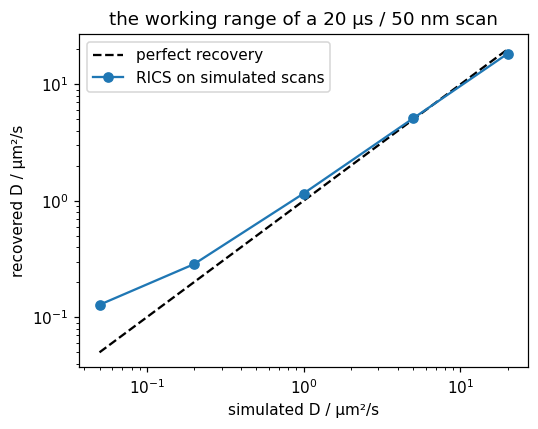

In [8]:
truths = [0.05, 0.2, 1.0, 5.0, 20.0]
recovered = []
for d in truths:
    s = simulate_clsm_diffusion(d, n_pixel=64, n_frames=40, n_molecules=400.0, seed=1)
    recovered.append(fit_rics(s)["D"])

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(truths, truths, "k--", label="perfect recovery")
ax.loglog(truths, recovered, "o-", label="RICS on simulated scans")
ax.set(xlabel="simulated D / µm²/s", ylabel="recovered D / µm²/s",
       title="the working range of a 20 µs / 50 nm scan")
ax.legend()
fig.tight_layout()

for d, r in zip(truths, recovered):
    ratio = r / d
    verdict = "recovered" if 0.7 < ratio < 1.5 else f"UNRELIABLE ({ratio:.1f}× off)"
    print(f"D = {d:5.2f} → {r:8.3f}   {verdict}")

Below about `D` = 1 µm²/s this scan stops being able to answer the question:
at `D` = 0.05 a molecule moves 2 nm between pixels and 16 nm between lines
against a 250 nm waist, so the correlation map is essentially the static focus.

**The failure is silent.** The fit does not refuse — it returns a confident
wrong number, 2.6× the truth at `D` = 0.05 and about 15× at `D` = 0.02.
Nothing in the output announces it. That is exactly why the scan-precision
planner (*Guides → Planning a scan*) exists: the working range is something to
check **before** the microscope time is spent, not after.

## 6. Three ways to simulate nothing at all

Each of the following produces a scan that looks entirely healthy — plausible
images, a plausible correlation map — and carries no diffusion information.
None of them raises an error.

### (a) Immobile molecules

The photon simulator marks emitters immobile by default, and an immobile
molecule ignores `D` completely. The images then come out **identical** for
every diffusion coefficient. `simulate_clsm_diffusion` sets the mobile flag for
you; the check below is what catches the mistake if you build a scan by hand.

In [9]:
slow = simulate_clsm_diffusion(1.0, n_pixel=32, n_frames=12, n_molecules=200.0, seed=3)
fast = simulate_clsm_diffusion(20.0, n_pixel=32, n_frames=12, n_molecules=200.0, seed=3)


def asymmetry(s):
    """G along the slow axis divided by G along the fast axis, at lag 4."""
    g = np.asarray(compute_ics_carpet(s.images).correlation[0], dtype=float)
    cy, cx = g.shape[0] // 2, g.shape[1] // 2
    return g[cy + 4, cx] / g[cy, cx + 4]


print(f"images identical?      {np.array_equal(slow.images, fast.images)}")
print(f"asymmetry at D =  1    {asymmetry(slow):.3f}")
print(f"asymmetry at D = 20    {asymmetry(fast):.3f}   (must be smaller)")

images identical?      False
asymmetry at D =  1    0.969
asymmetry at D = 20    0.791   (must be smaller)


### (b) Counting scanner markers as photons

A raster scan emits a marker per pixel plus line and frame markers. In a
typical scan these **outnumber the photons several times over**, so binning the
raw record stream builds an image that is mostly scanner bookkeeping — flat,
perfectly periodic, and correlating to nothing about the sample.

### (c) A closed volume

A fixed set of emitters diffuses out of the box and dies, so the concentration
falls through the acquisition. Every correlation analysis assumes a
**stationary** sample, so this quietly violates the one thing it relies on.
An open volume replenishes at the boundary, and the intensity stays level —
it drifts by under 10 % across the whole acquisition here, against the steady
decay a closed box would show:

first 5 frames: 16.73 counts/px
last  5 frames: 18.09 counts/px


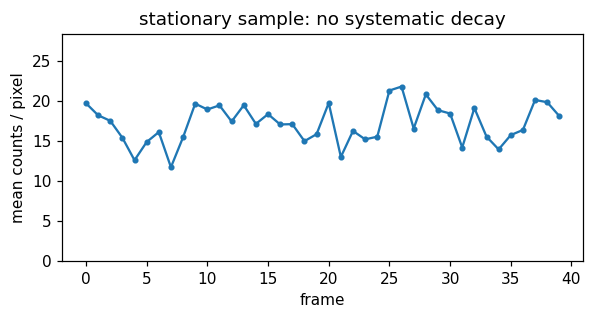

In [10]:
long_scan = simulate_clsm_diffusion(2.0, n_pixel=32, n_frames=40,
                                    n_molecules=300.0, seed=4)
per_frame = long_scan.images.mean(axis=(1, 2))

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(per_frame, "o-", ms=3)
ax.set(xlabel="frame", ylabel="mean counts / pixel",
       title="stationary sample: no systematic decay")
ax.set_ylim(0, per_frame.max() * 1.3)
fig.tight_layout()

print(f"first 5 frames: {per_frame[:5].mean():.2f} counts/px")
print(f"last  5 frames: {per_frame[-5:].mean():.2f} counts/px")

## Summary

* A raster scan measures diffusion because its two axes sample **different time
  scales**; the asymmetry between them is the entire signal.
* The simulation reproduces that, and RICS recovers `D` essentially unbiased
  (0.99× on average, 13 % scatter) across the range the scan can resolve.
* **Which lags you fit decides the answer.** Fit the slow axis, where the
  diffusion information is; the obvious square block of lags is mostly noise
  and drags `D` by tens of per cent in a `D`-dependent way.
* `N`, `D` and the beam waist are **degenerate**. Measure the waist; do not fit
  it, and do not guess it.
* Outside the working range the fit fails **silently**, returning a plausible
  number rather than an obvious one. Check the range in advance.

Next: *Guides → Planning a scan* chooses the dwell time before the experiment,
and the particle-tracking example does the same closed loop for single
particles rather than an ensemble.